In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = r"D:\TrustXAI"

READY_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "ready")
MODELS_PATH = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODELS_PATH, exist_ok=True)

DATA_FILE = os.path.join(
    READY_DATA_PATH,
    "TrustXAI_Encoded.csv"
)

print(DATA_FILE)

D:\TrustXAI\data\ready\TrustXAI_Encoded.csv


In [3]:
df = pd.read_csv(
    DATA_FILE,
    low_memory=False
)

print(df.shape)

(2827876, 85)


In [4]:
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df = df.drop(columns=columns_to_drop)

print("Dataset Shape:", df.shape)

X = df.drop("Label", axis=1)
y = df["Label"]

print("Features:", X.shape)
print("Labels:", y.shape)

Dataset Shape: (2827876, 81)
Features: (2827876, 80)
Labels: (2827876,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (2262300, 80)
Testing : (565576, 80)


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Started...")

rf_model.fit(X_train, y_train)

print("Training Finished.")

Training Started...
Training Finished.


In [7]:
y_pred = rf_model.predict(X_test)

print("Prediction Completed.")

Prediction Completed.


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*50)

Accuracy : 0.9994
Precision: 0.9994
Recall   : 0.9994
F1 Score : 0.9994


In [9]:
print(classification_report(
    y_test,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997    454265
           1     0.9661    0.9463    0.9561       391
           2     1.0000    0.9995    0.9997     25605
           3     0.9985    0.9937    0.9961      2059
           4     0.9980    0.9984    0.9982     46025
           5     0.9936    0.9918    0.9927      1100
           6     0.9974    0.9983    0.9978      1159
           7     1.0000    0.9994    0.9997      1587
           8     1.0000    1.0000    1.0000         2
           9     1.0000    0.5714    0.7273         7
          10     0.9997    0.9996    0.9996     31761
          11     1.0000    0.9992    0.9996      1180
          12     0.8224    0.8771    0.8489       301
          13     1.0000    0.2500    0.4000         4
          14     0.6887    0.5615    0.6186       130

    accuracy                         0.9994    565576
   macro avg     0.9643    0.8791    0.9023    565576
weighted avg     0.9994   

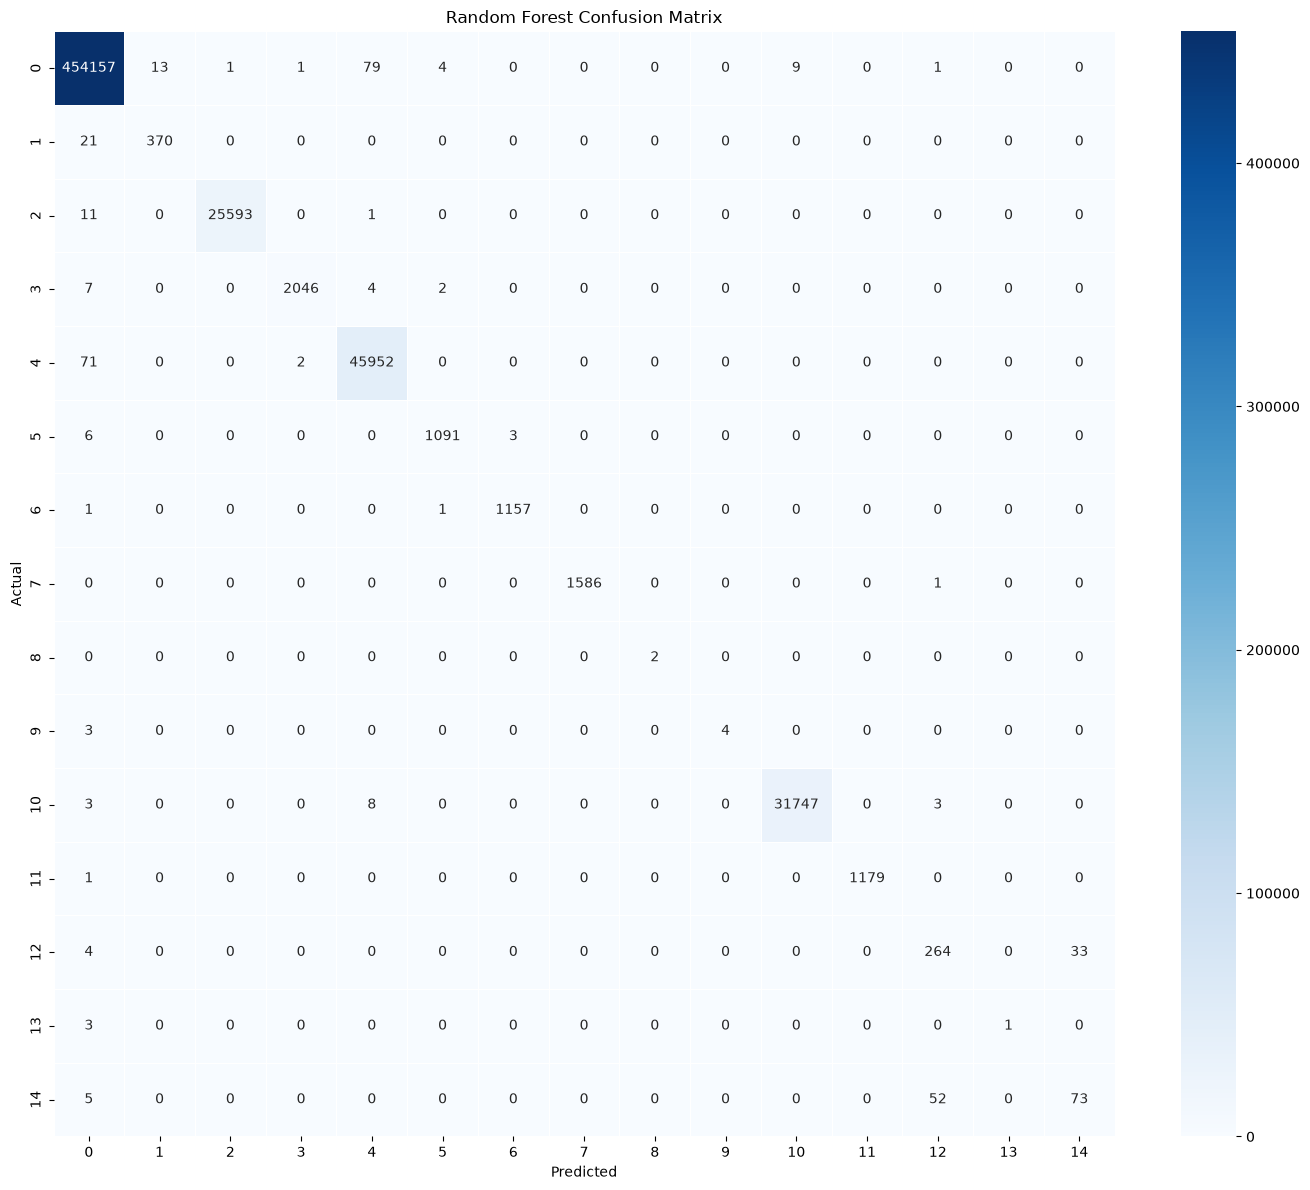

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "RandomForest_ConfusionMatrix.png",
    dpi=300
)

plt.show()

In [11]:
model_path = os.path.join(
    MODELS_PATH,
    "RandomForest_TrustXAI.pkl"
)

joblib.dump(rf_model, model_path)

print("Model Saved Successfully.")
print(model_path)

Model Saved Successfully.
D:\TrustXAI\models\RandomForest_TrustXAI.pkl


In [12]:
labels = pd.read_csv(
    DATA_FILE,
    usecols=["Label"]
)

print(labels["Label"].value_counts().sort_index())

Label
0     2271320
1        1956
2      128025
3       10293
4      230124
5        5499
6        5796
7        7935
8          11
9          36
10     158804
11       5897
12       1507
13         21
14        652
Name: count, dtype: int64
